In [ ]:
import sys
from pathlib import Path
import importlib
import warnings

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.fraud_pipeline as fraud_pipeline
from src.data_io import load_fraud_sources
importlib.reload(fraud_pipeline)
from src.fraud_pipeline import (
    clean_fraud_transactions,
    engineer_fraud_features,
    merge_fraud_with_country_lookup,
)

warnings.filterwarnings('ignore')
raw_dir = PROJECT_ROOT / 'data' / 'raw'
processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

fraud_df_raw, ip_df_raw = load_fraud_sources(raw_dir)
fraud_df = clean_fraud_transactions(fraud_df_raw)
merged = merge_fraud_with_country_lookup(fraud_df, ip_df_raw)
merged = engineer_fraud_features(merged)

print("Fraud_Data shape:", fraud_df.shape)
print("IP mapping shape:", ip_df_raw.shape)
print("Merged shape:", merged.shape)
fraud_df.head()

Fraud_Data shape: (151112, 11)
IP mapping shape: (138846, 3)
Merged shape: (151112, 20)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [24]:
print("=== Fraud_Data Info ===")
print(fraud_df.info())
print("\n=== Data Types ===")
print(fraud_df.dtypes)
print("\n=== Sample Rows ===")
fraud_df.head(10)

=== Fraud_Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB
None

=== Data Types ===
user_id                    int64
signup_time       datetime64[us]
purchase_time     

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0
5,159135,2015-05-21 06:03:03,2015-07-09 08:05:14,42,ALEYXFXINSXLZ,Ads,Chrome,M,18,2.809315e+09,0
6,50116,2015-08-01 22:40:52,2015-08-27 03:37:57,11,IWKVZHJOCLPUR,Ads,Chrome,F,19,3.987484e+09,0
7,360585,2015-04-06 07:35:45,2015-05-25 17:21:14,27,HPUCUYLMJBYFW,Ads,Opera,M,34,1.692459e+09,0
8,159045,2015-04-21 23:38:34,2015-06-02 14:01:54,30,ILXYDOZIHOOHT,SEO,IE,F,43,3.719094e+09,0
9,182338,2015-01-25 17:49:49,2015-03-23 23:05:42,62,NRFFPPHZYFUVC,Ads,IE,M,31,3.416747e+08,0


In [25]:
print("=== Missing Values ===")
print(fraud_df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(f"Duplicate count: {fraud_df.duplicated().sum()}")

# Drop duplicates
fraud_df.drop_duplicates(inplace=True)
print(f"\nShape after dropping duplicates: {fraud_df.shape}")

=== Missing Values ===
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

=== Duplicate Rows ===
Duplicate count: 0

Shape after dropping duplicates: (151112, 11)


In [27]:
# Convert timestamps to datetime
fraud_df['signup_time']   = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

print("signup_time dtype :", fraud_df['signup_time'].dtype)
print("purchase_time dtype:", fraud_df['purchase_time'].dtype)
fraud_df[['signup_time', 'purchase_time']].head()

signup_time dtype : datetime64[us]
purchase_time dtype: datetime64[us]


,signup_time,purchase_time
0,2015-02-24 22:55:49,2015-04-18 02:47:11
1,2015-06-07 20:39:50,2015-06-08 01:38:54
2,2015-01-01 18:52:44,2015-01-01 18:52:45
3,2015-04-28 21:13:25,2015-05-04 13:54:50
4,2015-07-21 07:09:52,2015-09-09 18:40:53


=== Class Distribution ===
        Count  Percentage
class                    
0      136961       90.64
1       14151        9.36


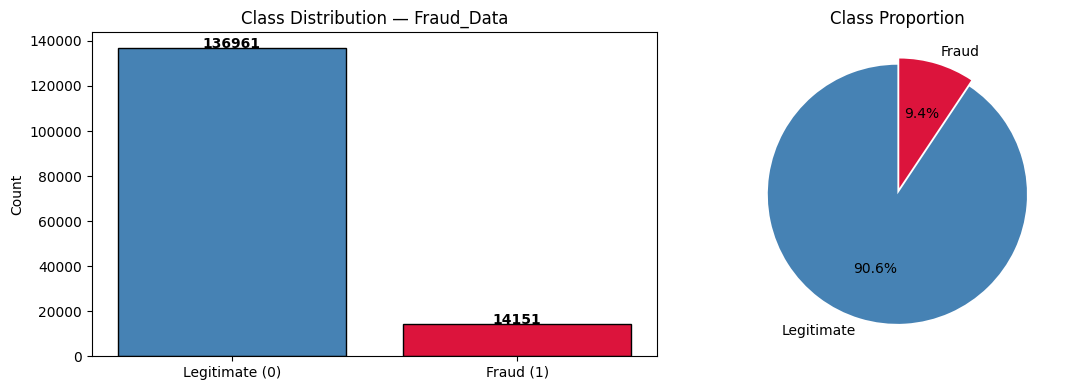

In [28]:
class_counts = fraud_df['class'].value_counts()
class_pct    = fraud_df['class'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
print(pd.DataFrame({'Count': class_counts, 'Percentage': class_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution — Fraud_Data')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.1f%%', colors=['steelblue', 'crimson'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('../data/processed/class_distribution_fraud.png', dpi=150)
plt.show()

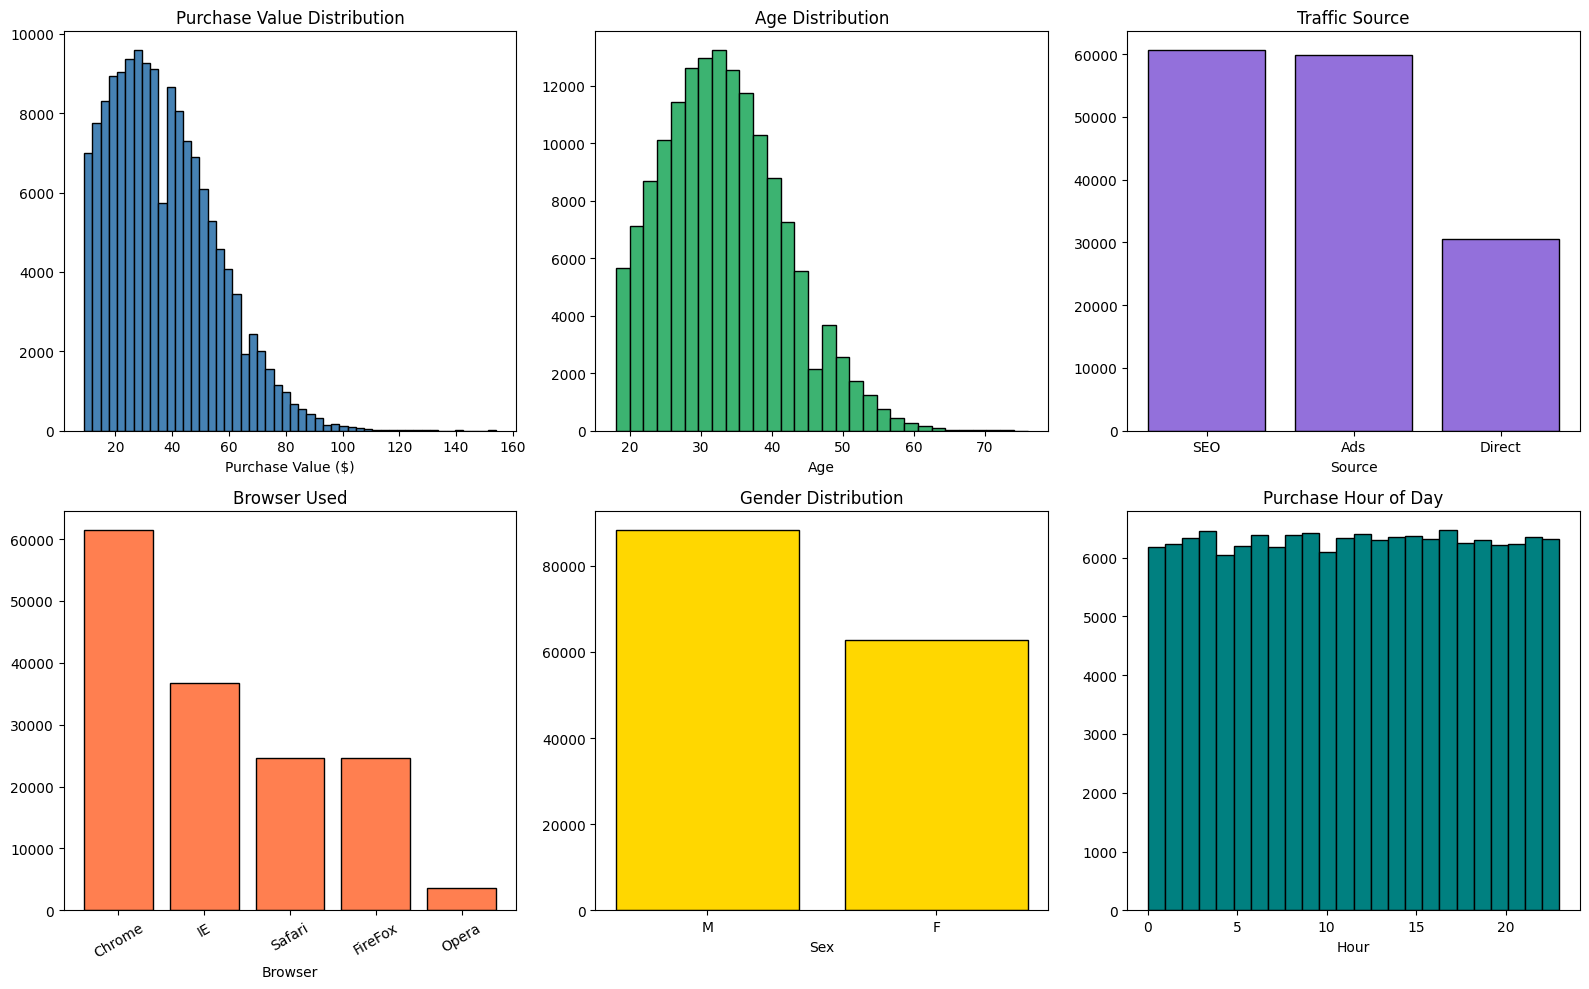

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Purchase value distribution
axes[0, 0].hist(fraud_df['purchase_value'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Purchase Value Distribution')
axes[0, 0].set_xlabel('Purchase Value ($)')

# Age distribution
axes[0, 1].hist(fraud_df['age'], bins=30, color='mediumseagreen', edgecolor='black')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')

# Source
source_counts = fraud_df['source'].value_counts()
axes[0, 2].bar(source_counts.index, source_counts.values, color='mediumpurple', edgecolor='black')
axes[0, 2].set_title('Traffic Source')
axes[0, 2].set_xlabel('Source')

# Browser
browser_counts = fraud_df['browser'].value_counts()
axes[1, 0].bar(browser_counts.index, browser_counts.values, color='coral', edgecolor='black')
axes[1, 0].set_title('Browser Used')
axes[1, 0].set_xlabel('Browser')
axes[1, 0].tick_params(axis='x', rotation=30)

# Sex
sex_counts = fraud_df['sex'].value_counts()
axes[1, 1].bar(sex_counts.index, sex_counts.values, color='gold', edgecolor='black')
axes[1, 1].set_title('Gender Distribution')
axes[1, 1].set_xlabel('Sex')

# Purchase hour (sneak peek)
fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour
axes[1, 2].hist(fraud_df['hour_of_day'], bins=24, color='teal', edgecolor='black')
axes[1, 2].set_title('Purchase Hour of Day')
axes[1, 2].set_xlabel('Hour')

plt.tight_layout()
plt.savefig('../data/processed/univariate_eda.png', dpi=150)
plt.show()

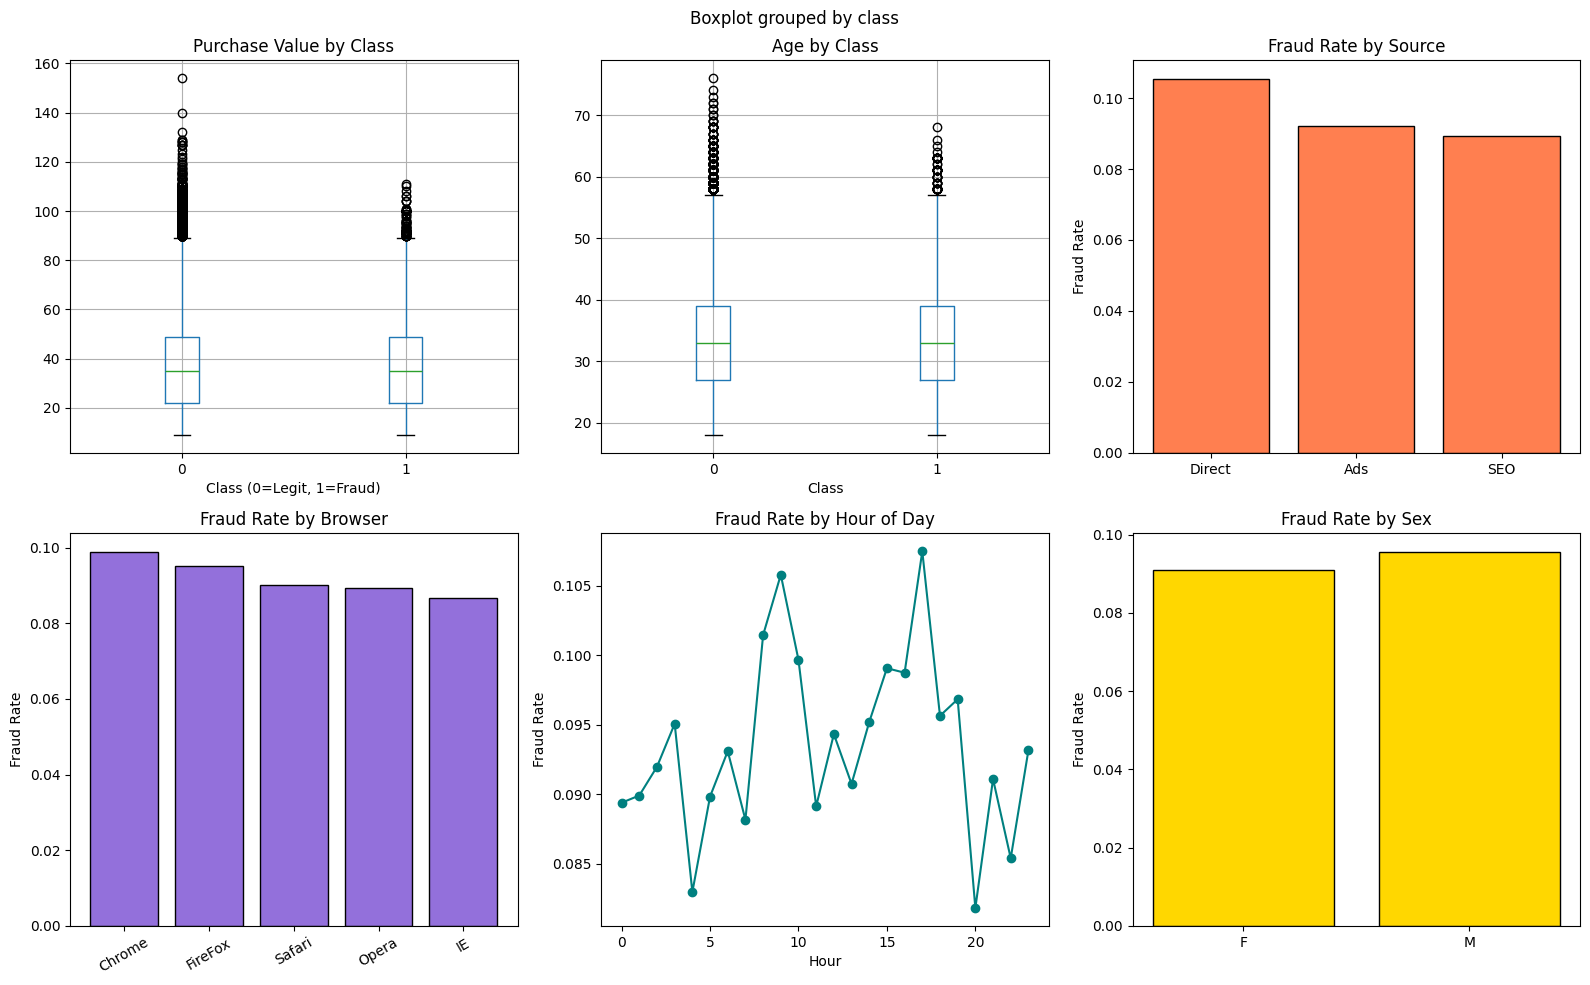

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Purchase value by class
fraud_df.boxplot(column='purchase_value', by='class', ax=axes[0, 0])
axes[0, 0].set_title('Purchase Value by Class')
axes[0, 0].set_xlabel('Class (0=Legit, 1=Fraud)')

# Age by class
fraud_df.boxplot(column='age', by='class', ax=axes[0, 1])
axes[0, 1].set_title('Age by Class')
axes[0, 1].set_xlabel('Class')

# Fraud rate by source
fraud_by_source = fraud_df.groupby('source')['class'].mean().sort_values(ascending=False)
axes[0, 2].bar(fraud_by_source.index, fraud_by_source.values, color='coral', edgecolor='black')
axes[0, 2].set_title('Fraud Rate by Source')
axes[0, 2].set_ylabel('Fraud Rate')

# Fraud rate by browser
fraud_by_browser = fraud_df.groupby('browser')['class'].mean().sort_values(ascending=False)
axes[1, 0].bar(fraud_by_browser.index, fraud_by_browser.values, color='mediumpurple', edgecolor='black')
axes[1, 0].set_title('Fraud Rate by Browser')
axes[1, 0].set_ylabel('Fraud Rate')
axes[1, 0].tick_params(axis='x', rotation=30)

# Fraud rate by hour
fraud_by_hour = fraud_df.groupby('hour_of_day')['class'].mean()
axes[1, 1].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', color='teal')
axes[1, 1].set_title('Fraud Rate by Hour of Day')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Fraud Rate')

# Fraud rate by sex
fraud_by_sex = fraud_df.groupby('sex')['class'].mean()
axes[1, 2].bar(fraud_by_sex.index, fraud_by_sex.values, color='gold', edgecolor='black')
axes[1, 2].set_title('Fraud Rate by Sex')
axes[1, 2].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.savefig('../data/processed/bivariate_eda.png', dpi=150)
plt.show()

In [34]:
print("Sample geolocation assignments:")
print(merged[['ip_address', 'country']].head())

print("Top countries in the enriched fraud data:")
print(merged['country'].value_counts().head(10))

Sample geolocation assignments:
     ip_address        country
0  8.802175e+08  United States
1  2.785906e+09    Switzerland
2  3.560567e+08  United States
3  7.591047e+08        Unknown
4  2.985180e+09         Mexico
Top countries in the enriched fraud data:
country
United States        58049
Unknown              21966
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Name: count, dtype: int64


In [35]:
country_fraud = (
    merged.groupby('country')['class']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'fraud_count', 'count': 'total'})
)
country_fraud['fraud_rate'] = country_fraud['fraud_count'] / country_fraud['total']
country_fraud = country_fraud[country_fraud['total'] >= 50]
print(country_fraud.sort_values('fraud_rate', ascending=False).head(10))

              fraud_count  total  fraud_rate
country                                     
Luxembourg             28     72    0.388889
Ecuador                28    106    0.264151
Tunisia                31    118    0.262712
Peru                   31    119    0.260504
Bolivia                13     53    0.245283
Kuwait                 21     90    0.233333
Ireland                55    240    0.229167
New Zealand            62    278    0.223022
Lithuania              18     95    0.189474
Saudi Arabia           50    264    0.189394


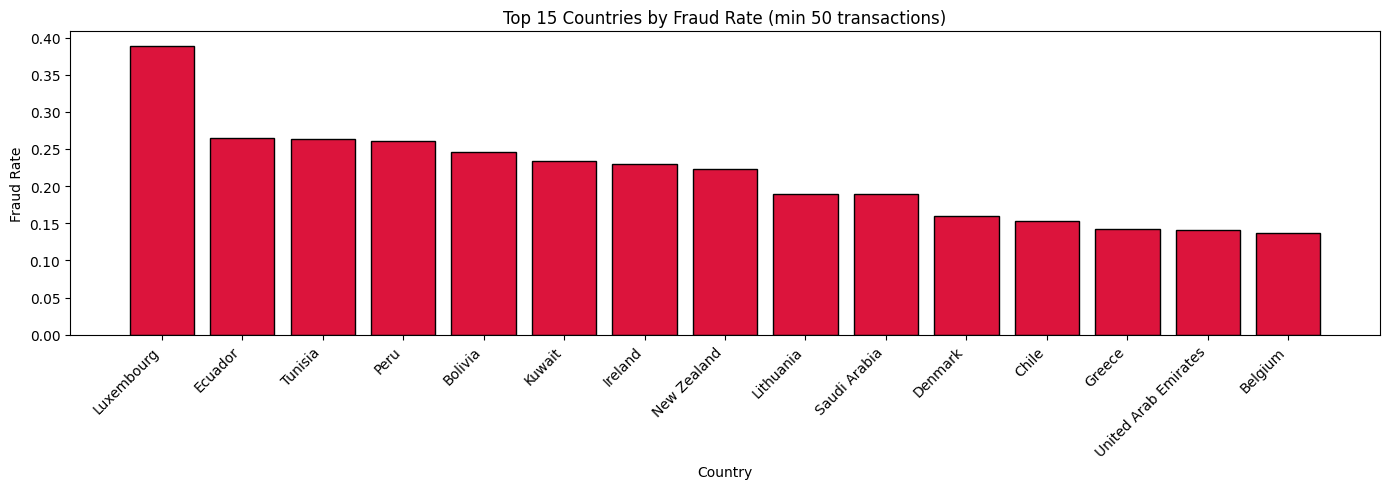

                      fraud_count  total  fraud_rate
country                                             
Luxembourg                     28     72       0.389
Ecuador                        28    106       0.264
Tunisia                        31    118       0.263
Peru                           31    119       0.261
Bolivia                        13     53       0.245
Kuwait                         21     90       0.233
Ireland                        55    240       0.229
New Zealand                    62    278       0.223
Lithuania                      18     95       0.189
Saudi Arabia                   50    264       0.189
Denmark                        78    490       0.159
Chile                          64    417       0.153
Greece                         33    231       0.143
United Arab Emirates           16    114       0.140
Belgium                        56    409       0.137


In [36]:
country_fraud = (
    merged.groupby('country')['class']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'fraud_count', 'count': 'total'})
)
country_fraud['fraud_rate'] = country_fraud['fraud_count'] / country_fraud['total']
country_fraud = country_fraud[country_fraud['total'] >= 50]  # filter low-volume
country_fraud_top = country_fraud.sort_values('fraud_rate', ascending=False).head(15)

plt.figure(figsize=(14, 5))
plt.bar(country_fraud_top.index, country_fraud_top['fraud_rate'], color='crimson', edgecolor='black')
plt.title('Top 15 Countries by Fraud Rate (min 50 transactions)')
plt.ylabel('Fraud Rate')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/fraud_by_country.png', dpi=150)
plt.show()

print(country_fraud_top[['fraud_count', 'total', 'fraud_rate']].round(3))

In [37]:
print("Engineered feature summary:")
print(merged[['time_since_signup', 'hour_of_day', 'day_of_week',
              'user_txn_count', 'device_txn_count']].describe())

Engineered feature summary:
       time_since_signup    hour_of_day    day_of_week  user_txn_count  \
count      151112.000000  151112.000000  151112.000000        151112.0   
mean         1370.008125      11.521593       3.011819             1.0   
std           868.406422       6.912474       2.006203             0.0   
min             0.000278       0.000000       0.000000             1.0   
25%           607.431528       6.000000       1.000000             1.0   
50%          1368.429306      12.000000       3.000000             1.0   
75%          2123.479028      17.000000       5.000000             1.0   
max          2879.992222      23.000000       6.000000             1.0   

       device_txn_count  
count     151112.000000  
mean           1.684367  
std            2.616954  
min            1.000000  
25%            1.000000  
50%            1.000000  
75%            1.000000  
max           20.000000  


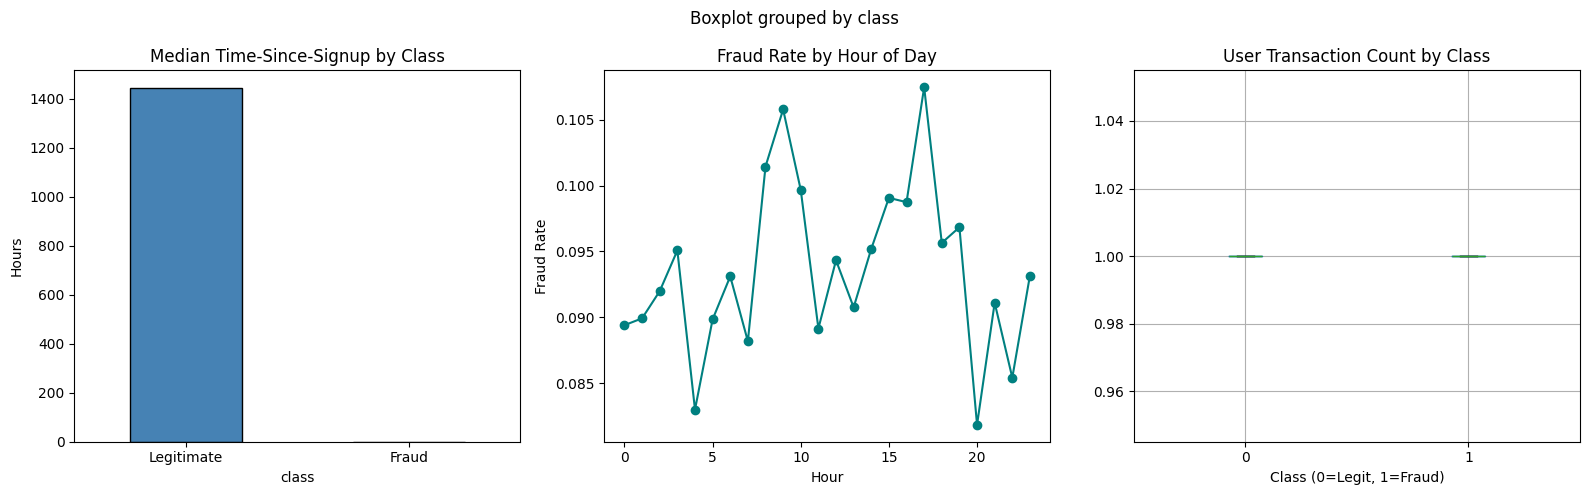

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Time since signup by class
merged.groupby('class')['time_since_signup'].median().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Median Time-Since-Signup by Class')
axes[0].set_ylabel('Hours')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

# Fraud rate by hour
fraud_hour = merged.groupby('hour_of_day')['class'].mean()
axes[1].plot(fraud_hour.index, fraud_hour.values, marker='o', color='teal')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')

# User transaction count by class
merged.boxplot(column='user_txn_count', by='class', ax=axes[2])
axes[2].set_title('User Transaction Count by Class')
axes[2].set_xlabel('Class (0=Legit, 1=Fraud)')

plt.tight_layout()
plt.savefig('../data/processed/feature_engineering_plots.png', dpi=150)
plt.show()

In [39]:
from src.fraud_pipeline import encode_and_scale_features

cat_cols = ['source', 'browser', 'sex', 'country']
num_cols = ['purchase_value', 'age', 'time_since_signup',
            'hour_of_day', 'day_of_week', 'user_txn_count', 'device_txn_count']

merged_encoded, feature_cols = encode_and_scale_features(merged, cat_cols, num_cols)
print("Feature columns count:", len(feature_cols))
merged_encoded[feature_cols].head()

Feature columns count: 195


,purchase_value,age,time_since_signup,hour_of_day,day_of_week,user_txn_count,device_txn_count,source_Direct,source_SEO,browser_FireFox,...,country_Unknown,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,0.931338,-0.944649,-0.437279,-0.220124,0.991020,0.0,-0.261514,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0.221836,0.563874,1.633857,1.371208,0.991020,0.0,-0.261514,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.549298,-0.944649,0.555032,-0.075457,-0.005891,0.0,-0.261514,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,1.367955,-1.408809,-1.458852,1.660541,-0.504347,0.0,-0.261514,False,True,True,...,True,False,False,False,False,False,False,False,False,False
4,-0.105627,-1.640890,-0.096136,1.226541,-0.504347,0.0,-0.261514,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [40]:
from src.fraud_pipeline import split_and_resample_features

split_results = split_and_resample_features(merged_encoded, feature_cols)
X_train = split_results['X_train']
X_test = split_results['X_test']
y_train = split_results['y_train']
y_test = split_results['y_test']
X_train_sm = split_results['X_train_sm']
y_train_sm = split_results['y_train_sm']

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train size: (120889, 195), Test size: (30223, 195)

Train class distribution:
class
0    109568
1     11321
Name: count, dtype: int64

Test class distribution:
class
0    27393
1     2830
Name: count, dtype: int64


=== Before SMOTE ===
class
0    109568
1     11321
Name: count, dtype: int64

=== After SMOTE ===
class
0    109568
1    109568
Name: count, dtype: int64


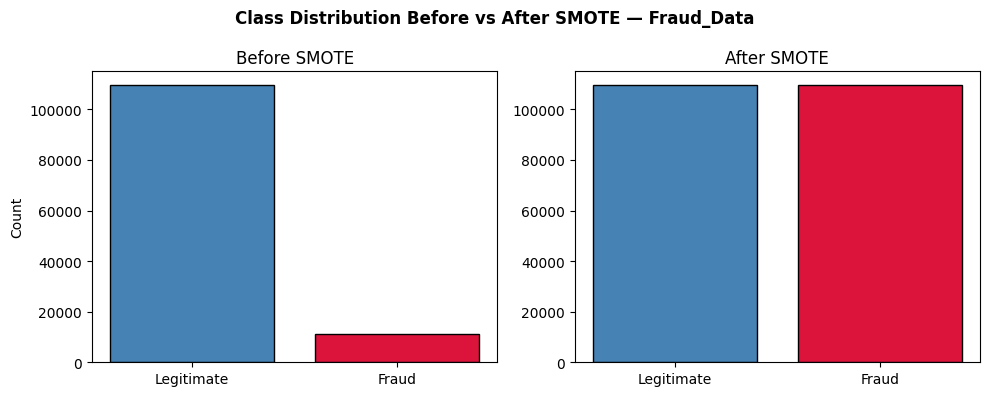

In [41]:
print("=== Before SMOTE ===")
print(y_train.value_counts())

print("\n=== After SMOTE ===")
print(pd.Series(y_train_sm).value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Legitimate', 'Fraud'], y_train.value_counts().values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

axes[1].bar(['Legitimate', 'Fraud'],
            pd.Series(y_train_sm).value_counts().sort_index().values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[1].set_title('After SMOTE')

plt.suptitle('Class Distribution Before vs After SMOTE — Fraud_Data', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/smote_comparison_fraud.png', dpi=150)
plt.show()

In [33]:
# Save the processed (pre-split) dataframe
merged_encoded.to_csv(processed_dir / 'fraud_data_processed.csv', index=False)
print("Saved: fraud_data_processed.csv")

# Optionally save train/test splits
import joblib
joblib.dump((X_train_sm, X_test, y_train_sm, y_test),
            processed_dir / 'fraud_train_test_splits.pkl')
print("Saved: fraud_train_test_splits.pkl")

Saved: fraud_data_processed.csv
Saved: fraud_train_test_splits.pkl
